In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/SampleSuperstore.csv', encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 13)

First 5 rows:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [24]:
# Check all column names and data types
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Columns: ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [25]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Basic Statistics:


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [26]:
# Check unique categories in key columns
print("Regions:", df['Region'].unique())
print("Segments:", df['Segment'].unique())
print("Categories:", df['Category'].unique())
print("Ship Modes:", df['Ship Mode'].unique())

print("\nValue Counts - Region:")
print(df['Region'].value_counts())

Regions: ['South' 'West' 'Central' 'East']


Segments: ['Consumer' 'Corporate' 'Home Office']
Categories: ['Furniture' 'Office Supplies' 'Technology']
Ship Modes: ['Second Class' 'Standard Class' 'First Class' 'Same Day']

Value Counts - Region:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


In [27]:
# Sales and Profit by Region
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
region_analysis['Profit Margin %'] = (
    (region_analysis['Profit'] / region_analysis['Sales']) * 100
).round(2)

region_analysis = region_analysis.sort_values('Sales', ascending=False)
print(region_analysis)

             Sales     Profit  Profit Margin %
Region                                        
West     725457.82  108418.45            14.94
East     678781.24   91522.78            13.48
Central  501239.89   39706.36             7.92
South    391721.90   46749.43            11.93


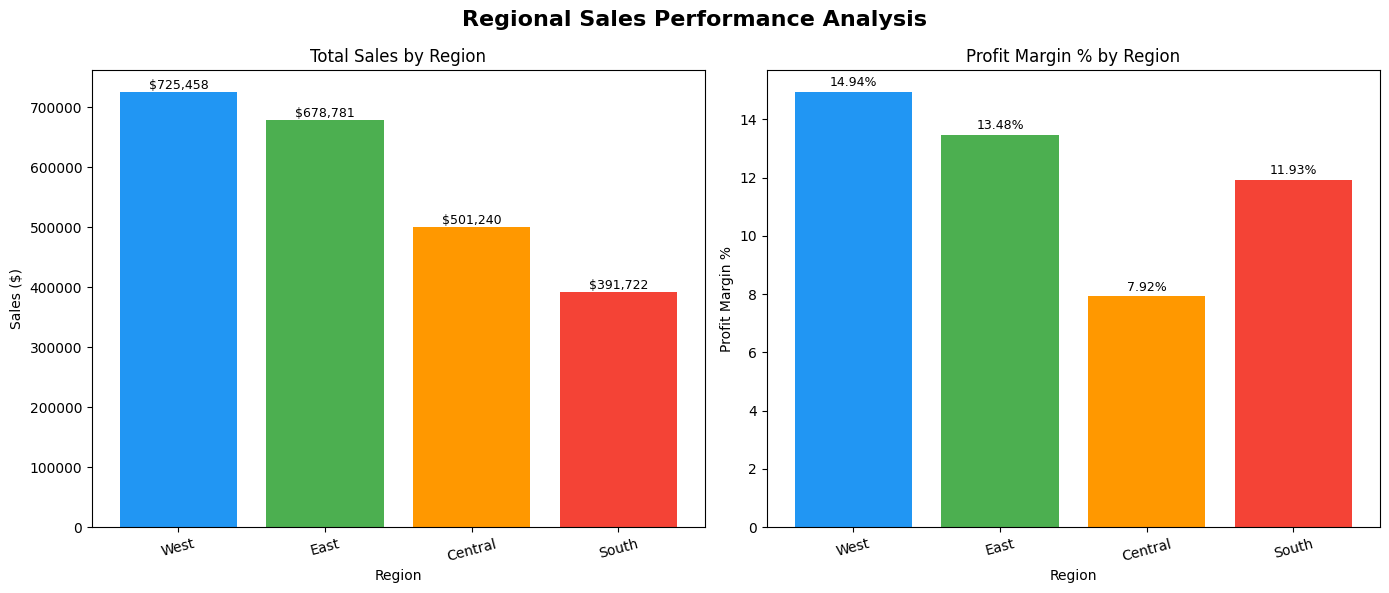

Chart saved to visuals folder!


In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Regional Sales Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Sales by Region
axes[0].bar(region_analysis.index, region_analysis['Sales'], 
            color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(region_analysis['Sales']):
    axes[0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 2 - Profit Margin by Region
axes[1].bar(region_analysis.index, region_analysis['Profit Margin %'],
            color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
axes[1].set_title('Profit Margin % by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=15)

for i, v in enumerate(region_analysis['Profit Margin %']):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/01_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to visuals folder!")

In [29]:
# Sales and Profit by Category
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
category_analysis['Profit Margin %'] = (
    (category_analysis['Profit'] / category_analysis['Sales']) * 100
).round(2)

category_analysis = category_analysis.sort_values('Profit', ascending=False)
print(category_analysis)

                     Sales     Profit  Profit Margin %
Category                                              
Technology       836154.03  145454.95            17.40
Office Supplies  719047.03  122490.80            17.04
Furniture        741999.80   18451.27             2.49


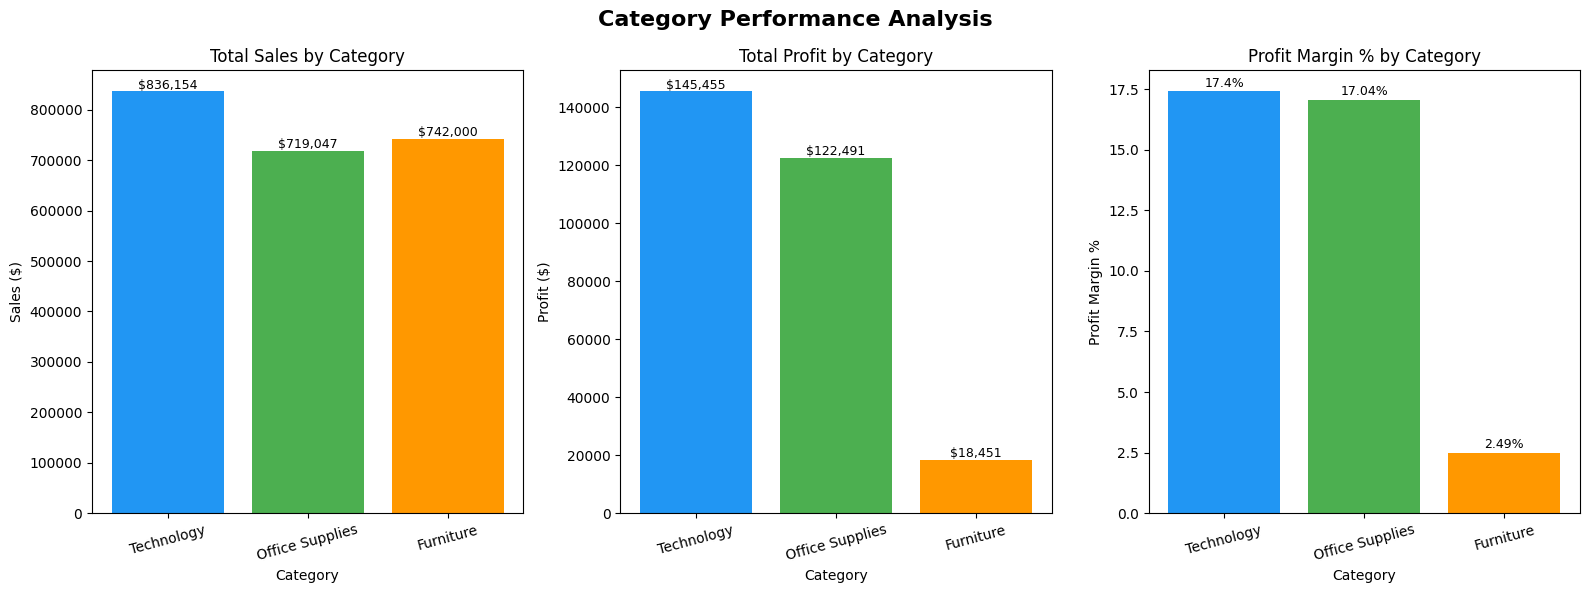

Chart saved!


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Category Performance Analysis', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800']

# Chart 1 - Sales by Category
axes[0].bar(category_analysis.index, category_analysis['Sales'], color=colors)
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(category_analysis['Sales']):
    axes[0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 2 - Profit by Category
axes[1].bar(category_analysis.index, category_analysis['Profit'], color=colors)
axes[1].set_title('Total Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(category_analysis['Profit']):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 3 - Profit Margin by Category
axes[2].bar(category_analysis.index, category_analysis['Profit Margin %'], color=colors)
axes[2].set_title('Profit Margin % by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Profit Margin %')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(category_analysis['Profit Margin %']):
    axes[2].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [31]:
# Sub-category analysis
subcat_analysis = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().round(2)
subcat_analysis['Profit Margin %'] = (
    (subcat_analysis['Profit'] / subcat_analysis['Sales']) * 100
).round(2)

subcat_analysis = subcat_analysis.sort_values('Profit', ascending=False)
print(subcat_analysis)

                  Sales    Profit  Profit Margin %
Sub-Category                                      
Copiers       149528.03  55617.82            37.20
Phones        330007.05  44515.73            13.49
Accessories   167380.32  41936.64            25.05
Paper          78479.21  34053.57            43.39
Binders       203412.73  30221.76            14.86
Chairs        328449.10  26590.17             8.10
Storage       223843.61  21278.83             9.51
Appliances    107532.16  18138.01            16.87
Furnishings    91705.16  13059.14            14.24
Envelopes      16476.40   6964.18            42.27
Art            27118.79   6527.79            24.07
Labels         12486.31   5546.25            44.42
Machines      189238.63   3384.76             1.79
Fasteners       3024.28    949.52            31.40
Supplies       46673.54  -1189.10            -2.55
Bookcases     114880.00  -3472.56            -3.02
Tables        206965.53 -17725.48            -8.56


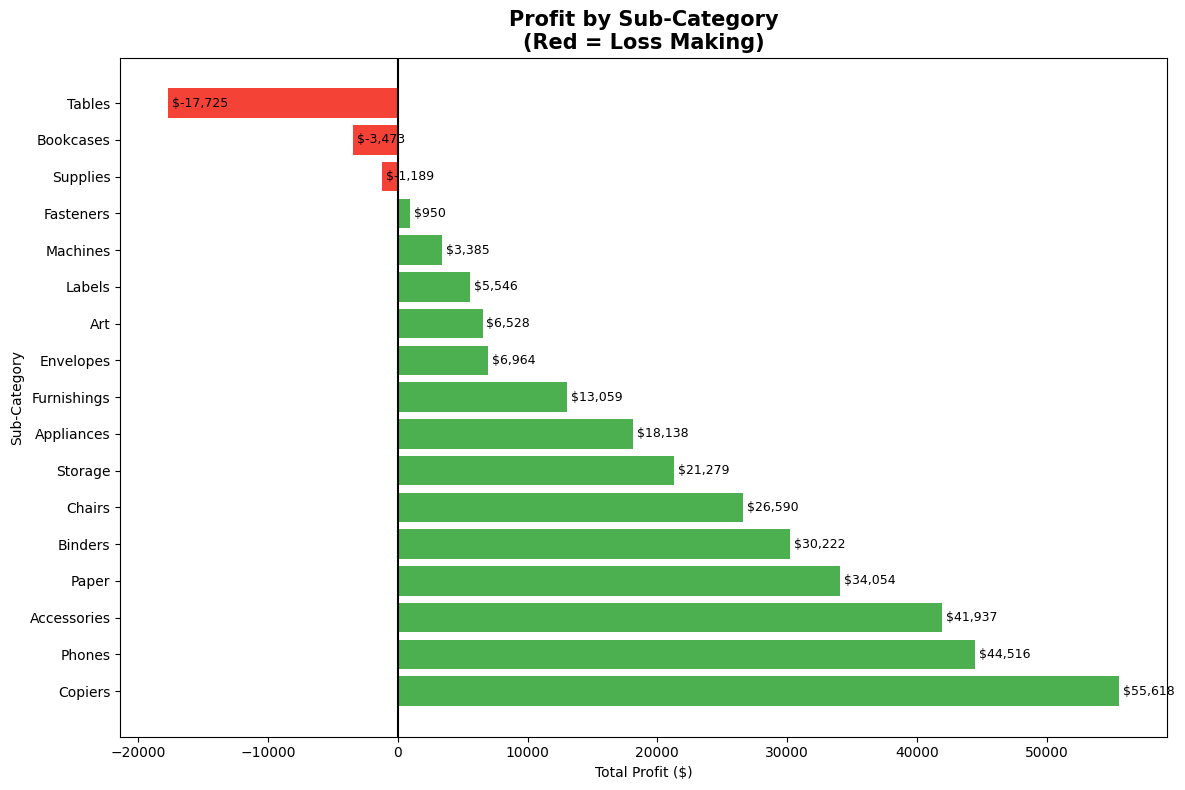

Chart saved!


In [32]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#F44336' if x < 0 else '#4CAF50' for x in subcat_analysis['Profit']]

ax.barh(subcat_analysis.index, subcat_analysis['Profit'], color=colors)
ax.set_title('Profit by Sub-Category\n(Red = Loss Making)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.set_ylabel('Sub-Category')
ax.axvline(x=0, color='black', linewidth=1.5)

for i, v in enumerate(subcat_analysis['Profit']):
    ax.text(v + 300, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/03_subcategory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [33]:
# Discount vs Profit Analysis
discount_analysis = df.groupby('Discount')[['Sales', 'Profit']].mean().round(2)
print(discount_analysis)

# Correlation check
correlation = df['Discount'].corr(df['Profit'])
print(f"\nCorrelation between Discount and Profit: {correlation:.4f}")

           Sales  Profit
Discount                
0.00      226.74   66.90
0.10      578.40   96.06
0.15      529.97   27.29
0.20      209.08   24.70
0.30      454.74  -45.68
0.32      536.79  -88.56
0.40      565.13 -111.93
0.45      498.63 -226.65
0.50      892.71 -310.70
0.60       48.15  -43.08
0.70       97.18  -95.87
0.80       56.55 -101.80

Correlation between Discount and Profit: -0.2195


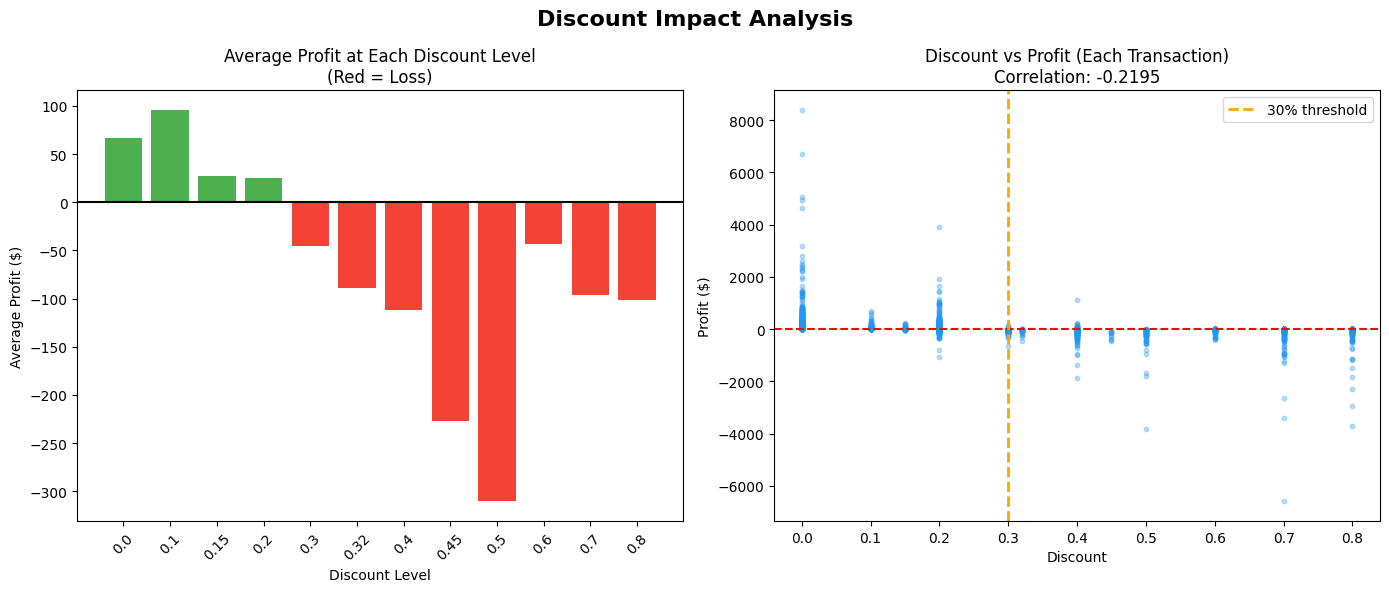

Chart saved!


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Discount Impact Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Discount vs Average Profit
colors = ['#F44336' if x < 0 else '#4CAF50' for x in discount_analysis['Profit']]
axes[0].bar(discount_analysis.index.astype(str), discount_analysis['Profit'], color=colors)
axes[0].set_title('Average Profit at Each Discount Level\n(Red = Loss)', fontsize=12)
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Average Profit ($)')
axes[0].axhline(y=0, color='black', linewidth=1.5)
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - Scatter plot Discount vs Profit
axes[1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#2196F3', s=10)
axes[1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1].axvline(x=0.3, color='orange', linewidth=2, linestyle='--', label='30% threshold')
axes[1].set_title(f'Discount vs Profit (Each Transaction)\nCorrelation: {correlation:.4f}', fontsize=12)
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/04_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [35]:
# Segment Analysis
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)
segment_analysis['Profit Margin %'] = (
    (segment_analysis['Profit'] / segment_analysis['Sales']) * 100
).round(2)

segment_analysis = segment_analysis.sort_values('Profit', ascending=False)
print(segment_analysis)

                  Sales     Profit  Profit Margin %
Segment                                            
Consumer     1161401.34  134119.21            11.55
Corporate     706146.37   91979.13            13.03
Home Office   429653.15   60298.68            14.03


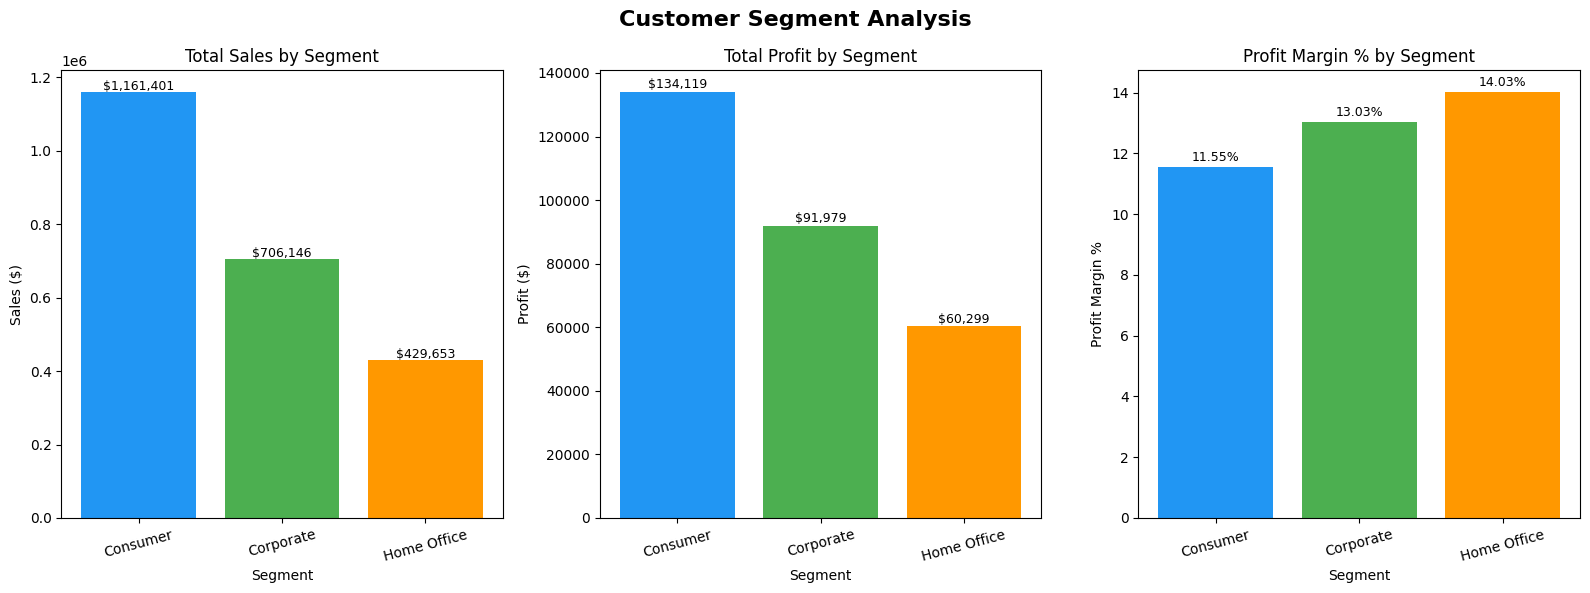

Chart saved!


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800']

# Chart 1 - Sales by Segment
axes[0].bar(segment_analysis.index, segment_analysis['Sales'], color=colors)
axes[0].set_title('Total Sales by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(segment_analysis['Sales']):
    axes[0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 2 - Profit by Segment
axes[1].bar(segment_analysis.index, segment_analysis['Profit'], color=colors)
axes[1].set_title('Total Profit by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(segment_analysis['Profit']):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)

# Chart 3 - Profit Margin by Segment
axes[2].bar(segment_analysis.index, segment_analysis['Profit Margin %'], color=colors)
axes[2].set_title('Profit Margin % by Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Profit Margin %')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(segment_analysis['Profit Margin %']):
    axes[2].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/05_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Category  Furniture  Office Supplies  Technology
Region                                          
Central    -2871.05          8879.98    33697.43
East        3046.17         41014.58    47462.04
South       6771.21         19986.39    19991.83
West       11504.95         52609.85    44303.65


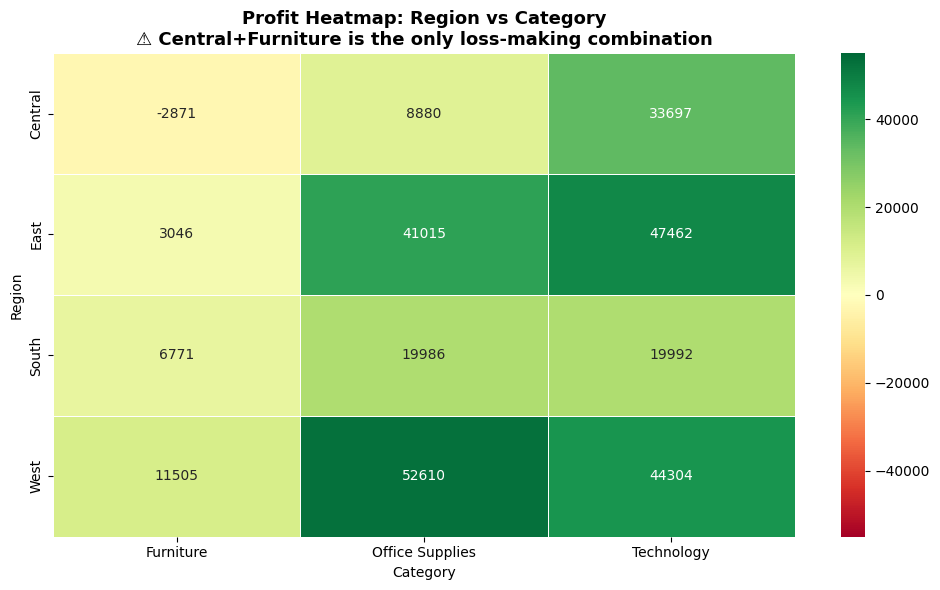

Chart saved!


In [37]:
# Region x Category Heatmap
pivot_profit = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
).round(2)

print(pivot_profit)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_profit, 
            annot=True,           
            fmt='.0f',            
            cmap='RdYlGn',        
            center=0,
            vmin=-55000,
            vmax=55000,             
            linewidths=0.5)

plt.title('Profit Heatmap: Region vs Category\n⚠️ Central+Furniture is the only loss-making combination', 
          fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('../visuals/06_heatmap_region_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# Step 1 - Create target variable
df['Profitable'] = (df['Profit'] > 0).astype(int)

print("Profitable vs Loss distribution:")
print(df['Profitable'].value_counts())
print(f"\nProfitable %: {df['Profitable'].mean()*100:.1f}%")

Profitable vs Loss distribution:
Profitable
1    8058
0    1936
Name: count, dtype: int64

Profitable %: 80.6%


In [39]:
# Step 2 - Prepare features
le = LabelEncoder()

# Copy relevant columns
ml_df = df[['Region', 'Category', 'Segment', 'Ship Mode', 
            'Discount', 'Quantity', 'Sales', 'Profitable']].copy()

# Convert text columns to numbers
ml_df['Region'] = le.fit_transform(ml_df['Region'])
ml_df['Category'] = le.fit_transform(ml_df['Category'])
ml_df['Segment'] = le.fit_transform(ml_df['Segment'])
ml_df['Ship Mode'] = le.fit_transform(ml_df['Ship Mode'])

print("Data ready for ML:")
print(ml_df.head())
print(f"\nShape: {ml_df.shape}")

Data ready for ML:
   Region  Category  Segment  Ship Mode  Discount  Quantity     Sales  \
0       2         0        0          2      0.00         2  261.9600   
1       2         0        0          2      0.00         3  731.9400   
2       3         1        1          2      0.00         2   14.6200   
3       2         0        0          3      0.45         5  957.5775   
4       2         1        0          3      0.20         2   22.3680   

   Profitable  
0           1  
1           1  
2           1  
3           0  
4           1  

Shape: (9994, 8)


In [40]:
# Step 3 - Split data and train model
X = ml_df.drop('Profitable', axis=1)  # Features (inputs)
y = ml_df['Profitable']                # Target (what we predict)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully! ✅")

# Test accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Training samples: 7995
Testing samples: 1999

Model trained successfully! ✅
Model Accuracy: 93.55%


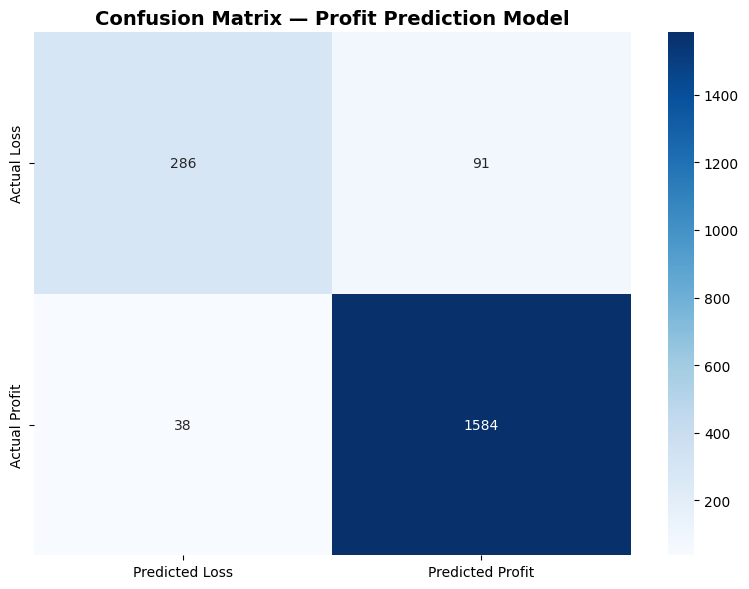

Detailed Classification Report:
              precision    recall  f1-score   support

        Loss       0.88      0.76      0.82       377
  Profitable       0.95      0.98      0.96      1622

    accuracy                           0.94      1999
   macro avg       0.91      0.87      0.89      1999
weighted avg       0.93      0.94      0.93      1999



In [41]:
# Step 4 - Confusion Matrix & Detailed Report
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Profit'],
            yticklabels=['Actual Loss', 'Actual Profit'])
plt.title('Confusion Matrix — Profit Prediction Model', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed Report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Loss', 'Profitable']))

     Feature  Importance
4   Discount    0.604235
6      Sales    0.221405
5   Quantity    0.057000
1   Category    0.039650
0     Region    0.039258
2    Segment    0.019291
3  Ship Mode    0.019161


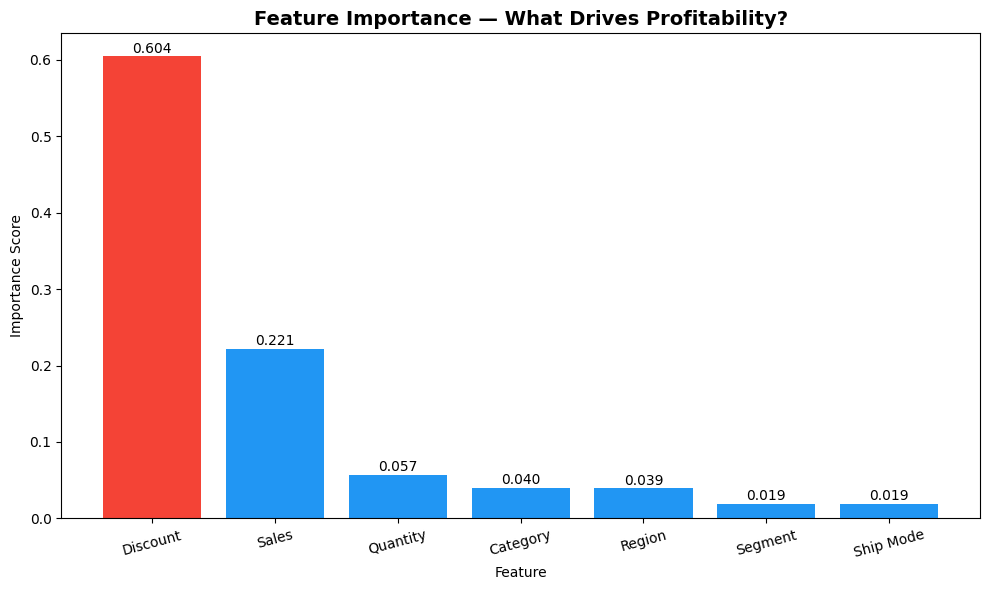

Chart saved!


In [42]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], 
        feature_importance['Importance'],
        color=['#F44336' if i == 0 else '#2196F3' 
               for i in range(len(feature_importance))])
plt.title('Feature Importance — What Drives Profitability?', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
for i, v in enumerate(feature_importance['Importance']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [43]:
# Prepare enriched dataset for Power BI
powerbi_df = df.copy()

# Add our calculated columns
powerbi_df['Profitable'] = (powerbi_df['Profit'] > 0).astype(int)
powerbi_df['Profit Margin %'] = (
    (powerbi_df['Profit'] / powerbi_df['Sales']) * 100
).round(2)
powerbi_df['Profit Status'] = powerbi_df['Profitable'].map(
    {1: 'Profitable', 0: 'Loss'}
)
powerbi_df['Discount Band'] = pd.cut(
    powerbi_df['Discount'],
    bins=[-1, 0, 0.2, 0.3, 1.0],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-30%)', 'High (30%+)']
)

# Export to CSV
powerbi_df.to_csv('../data/superstore_powerbi.csv', index=False)

print("Exported successfully! ✅")
print(f"Shape: {powerbi_df.shape}")
print(f"\nNew columns added:")
print(powerbi_df[['Profitable', 'Profit Margin %', 
                   'Profit Status', 'Discount Band']].head())

Exported successfully! ✅
Shape: (9994, 17)

New columns added:
   Profitable  Profit Margin % Profit Status Discount Band
0           1            16.00    Profitable   No Discount
1           1            30.00    Profitable   No Discount
2           1            47.00    Profitable   No Discount
3           0           -40.00          Loss   High (30%+)
4           1            11.25    Profitable   Low (1-20%)
